# Summary of triaging

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from regseq2.viz import matplotlib_style

matplotlib_style()

In [2]:
df_triage = pd.read_csv("triaging.csv")
df_triage['promoter']
df_triage.head()

,promoter,gc,rep,cv,cv_smooth,entropy,entropy_smooth,classification
0,araBp,29,2,5.105271,1.938526,4.787686,6.292157,1
1,mglBp,9,2,4.801802,1.775373,4.960044,6.371064,1
2,araBp,41,2,4.614532,1.676568,5.100020,6.498608,1
3,araBp,9,2,4.604240,1.720245,5.004471,6.446054,1
4,araBp,13,2,4.586132,1.671479,5.070243,6.494205,1


In [3]:
df_2 =  df_triage[df_triage.classification == 2].groupby(['promoter']).apply(len, include_groups=False).reset_index()
df_1 =  df_triage[df_triage.classification == 1].groupby(['promoter']).apply(len, include_groups=False).reset_index()
df_0 =  df_triage[df_triage.classification == 0].groupby(['promoter']).apply(len, include_groups=False).reset_index()
df = df_1.merge(df_2, on='promoter', how='outer')
df = df.merge(df_0, on='promoter', how='outer')
df.rename(columns={0: 'class_0', '0_x': "class_1", '0_y': "class_2"}, inplace=True)
df.fillna(0, inplace=True)

In [4]:
df

,promoter,class_1,class_2,class_0
0,TSS_1414_storz_regulondb,0.0,40.0,48
1,TSS_18061_regulondb,2.0,8.0,78
2,TSS_4654_wanner_regulondb,0.0,0.0,88
3,TSS_4655_regulondb,1.0,1.0,86
4,TSS_6311_regulondb,0.0,4.0,84
...,...,...,...,...
107,yncEp,1.0,21.0,66
108,yqaEp,0.0,13.0,75
109,yqjE_yqjK_yqjD_yqjC_predicted,0.0,80.0,8
110,zapB_predicted,0.0,74.0,14


In [5]:
tss_names = {
    "TSS_1414_storz_regulondb": 'yahM',
    'TSS_18061_regulondb': 'yjjJ',
    'TSS_4654_wanner_regulondb': 'ymfJ',
    'TSS_4655_regulondb': 'ymfJ_2',
    'TSS_6311_regulondb': 'dicA',
}

In [6]:
# Build group keys
is_pred = df['promoter'].str.contains(r'predicted', case=False, na=False)
is_tss  = df['promoter'].str.contains(r'TSS', case=False, na=False)

# Assign sort groups: normal=0, TSS=1, predicted=2
df = df.assign(
    _group = (0
              + is_tss.astype(int)          # TSS → 1
              + is_pred.astype(int) * 2)    # predicted → 2 (overrides TSS if both match)
)

# Sort first by group, then by any other column(s) you like
df_sorted = (
    df.sort_values(
        by=['_group'],   # change 'score' to your sorting column(s)
        ascending=[True],  # within each group, sort descending by score
        kind='mergesort'          # stable sort keeps input order when ties
    )
    .drop(columns='_group')
)

print(df_sorted)

                                              promoter  class_1  class_2  \
5                                                aceBp      1.0     80.0   
6                                                acrAp      0.0     61.0   
7                                                acrBp      0.0      3.0   
8                                                acrZp      0.0     85.0   
9                                                araBp     45.0      3.0   
..                                                 ...      ...      ...   
103                                     ygiW_predicted      1.0      8.0   
104                                     yjbJ_predicted      0.0     26.0   
106  ymfM_beeE_jayE_ymfL_ymfR_tfaP_ymfT_ymfN_ycfK_y...      7.0      1.0   
109                      yqjE_yqjK_yqjD_yqjC_predicted      0.0     80.0   
110                                     zapB_predicted      0.0     74.0   

     class_0  
5          7  
6         27  
7         85  
8          3  
9         40

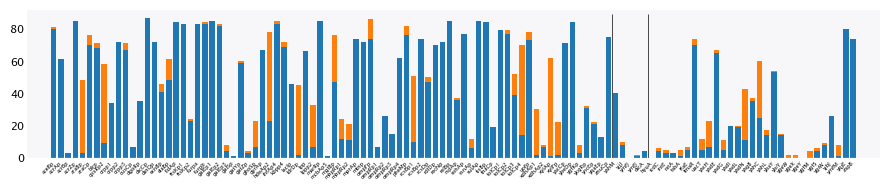

In [7]:
fig, ax = plt.subplots(figsize=(9, 2))
ax.bar(np.arange(len(df_sorted)), df_sorted['class_2'], width=0.75)
ax.bar(np.arange(len(df_sorted)), df_sorted['class_1'], bottom=df_sorted['class_2'], width=0.75, )

labels = [tss_names[x] if x in tss_names.keys() else x for x in df_sorted.promoter]
labels = [x.split('_')[0] for x in labels]
ax.set_xticks(np.arange(len(df_sorted)) + 0.25, labels, rotation=45, fontsize=4, ha='right');


ax.vlines(len(df_sorted) - np.sum(is_tss) - np.sum(is_pred) - 0.5, 0, 89, linewidth=0.5, color='black')
ax.vlines(len(df_sorted) - np.sum(is_pred) - 0.5, 0, 89, linewidth=0.5, color='black')
plt.grid(False)
fig.tight_layout()
#fig.savefig('expression_sum.pdf')

(array([37., 10.,  9.,  2.,  6.,  4.,  2.,  8., 17., 17.]),
 array([ 0. ,  8.7, 17.4, 26.1, 34.8, 43.5, 52.2, 60.9, 69.6, 78.3, 87. ]),
 <BarContainer object of 10 artists>)

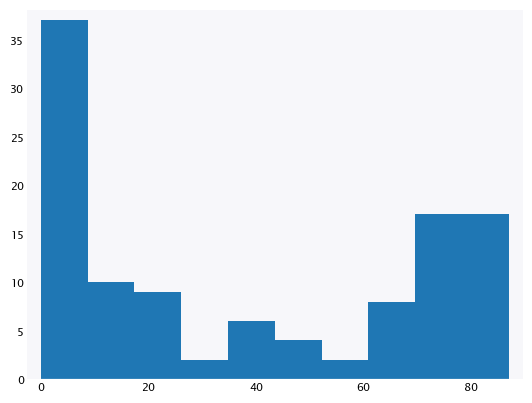

In [8]:
plt.hist(df['class_2'])